In [1]:
# Employee Salary Prediction using Machine Learning

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

In [2]:
df = pd.read_csv("../data/Salary_dataset.csv")

df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [4]:
# Check for missing values
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [5]:
# Summary statistics
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


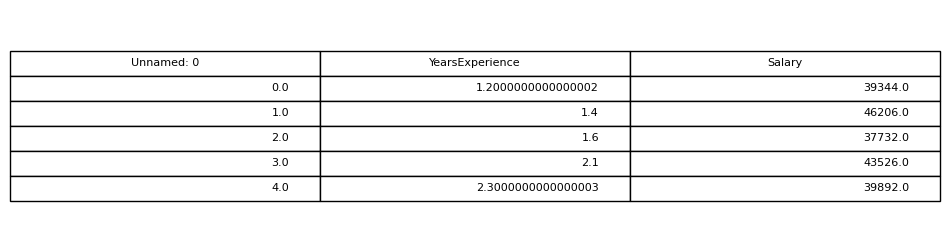

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')

table = ax.table(
    cellText=df.head().values,
    colLabels=df.head().columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)

plt.savefig("../images/dataset_head.png",
            bbox_inches='tight',
            dpi=300)

plt.show()

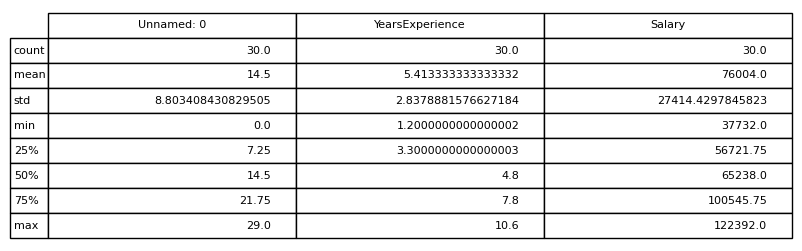

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')

table = ax.table(
    cellText=df.describe().values,
    colLabels=df.describe().columns,
    rowLabels=df.describe().index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)

plt.savefig("../images/dataset_statistics.png",
            bbox_inches='tight',
            dpi=300)

plt.show()

In [8]:
# Number of rows and columns
print("Shape of dataset:", df.shape)

Shape of dataset: (30, 3)


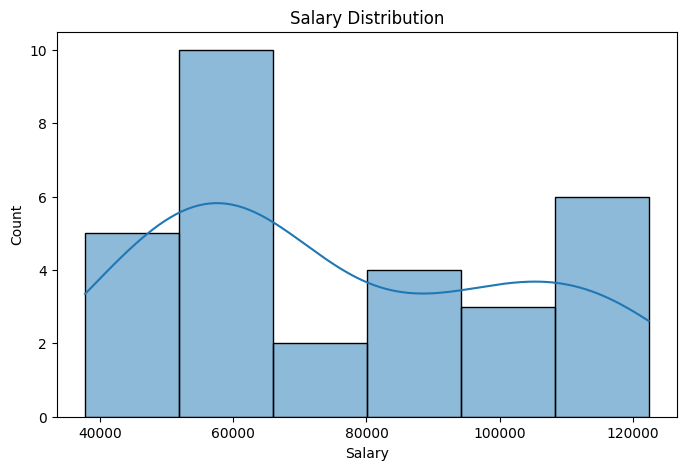

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], kde=True)

plt.title("Salary Distribution")
plt.savefig("../images/salary_distribution.png")
plt.show()

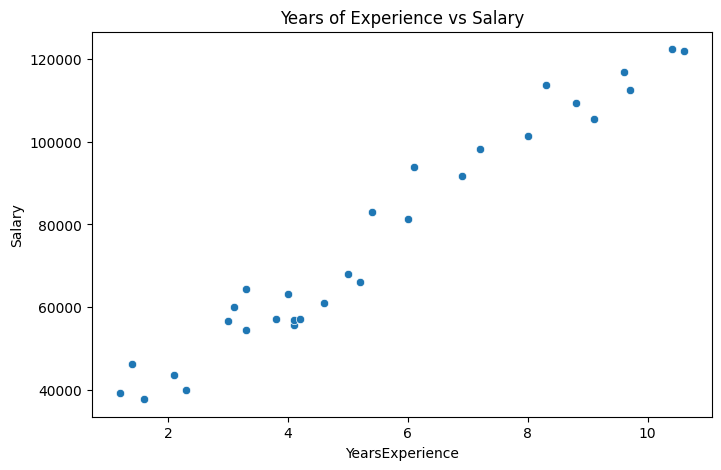

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="YearsExperience", y="Salary", data=df)

plt.title("Years of Experience vs Salary")
plt.savefig("../images/experience_vs_salary.png")
plt.show()

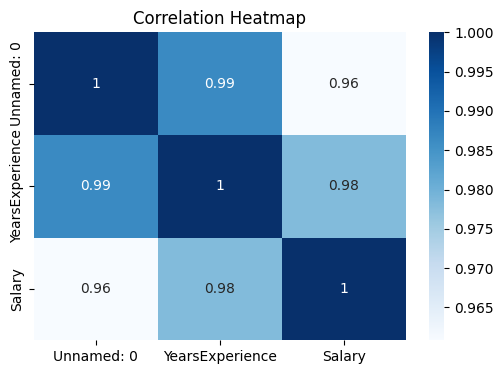

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")
plt.show()

In [12]:
X = df[["YearsExperience"]]

y = df["Salary"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
y_pred = lr.predict(X_test)

In [16]:
print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 6286.453830757745
MSE: 49830096.855908334
R2 Score: 0.9024461774180498


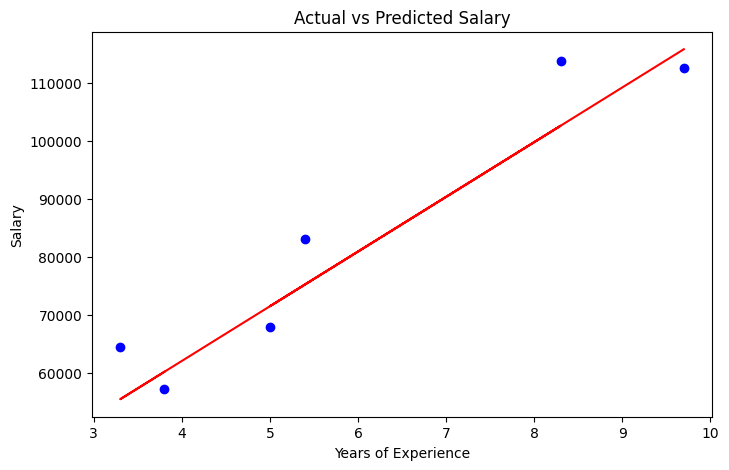

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, color="blue")

plt.plot(X_test, y_pred, color="red")

plt.title("Actual vs Predicted Salary")

plt.xlabel("Years of Experience")

plt.ylabel("Salary")

plt.savefig("../images/prediction_graph.png")

plt.show()

In [18]:
pickle.dump(lr, open("../model/salary_prediction_model.pkl", "wb"))

In [19]:
predictions = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

predictions.to_csv("../model/predictions.csv", index=False)

predictions.head()

,Actual Salary,Predicted Salary
27,112636.0,115791.210113
15,67939.0,71499.278095
23,113813.0,102597.868661
17,83089.0,75268.804224
8,64446.0,55478.792045
